# 1. Imports

In [14]:
%pip install pandas nltk scikit-learn matplotlib gensim

import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt

nltk.download("stopwords")


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/andydoce/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 2. Convertir CSV a TXT limpio


In [15]:
# ==========================================
# LIMPIEZA DEL CSV Y GENERACIÓN DEL TXT
# ==========================================

import pandas as pd
import re

csv_path = "tweets.csv"

# Nombre del archivo TXT que se generará después de limpiar el CSV
txt_path = "tweets_limpios.txt"

# Se carga el archivo CSV.
df_csv = pd.read_csv(csv_path)

# Se muestran las columnas del CSV para verificar que exista tweet_text
print("Columnas encontradas en el CSV:")
print(df_csv.columns)

# Se valida que la columna tweet_text exista dentro del archivo CSV
if "tweet_text" not in df_csv.columns:
    raise ValueError("No se encontró la columna 'tweet_text' en el CSV. Revisa el nombre exacto de la columna.")

# Nos quedamos únicamente con la columna tweet_text
df_csv = df_csv[["tweet_text"]].copy()

# Eliminamos filas vacías en tweet_text
df_csv = df_csv.dropna(subset=["tweet_text"])

# Función para limpiar el texto de cada tweet
def limpiar_tweet(texto):
    texto = str(texto)                                      # asegurar que el dato sea texto
    texto = re.sub(r"http\S+|www\S+", " ", texto)         # eliminar links
    texto = re.sub(r"@\w+", " ", texto)                   # eliminar menciones
    texto = re.sub(r"#", " ", texto)                       # quitar símbolo # y conservar palabra
    texto = re.sub(r"\s+", " ", texto).strip()             # quitar espacios extra
    return texto

# Se aplica la limpieza a la columna tweet_text
df_csv["tweet_text"] = df_csv["tweet_text"].apply(limpiar_tweet)

# Se eliminan tweets que hayan quedado vacíos después de la limpieza
df_csv = df_csv[df_csv["tweet_text"] != ""]

# Se guarda solo el contenido de tweet_text en formato TXT
# Cada tweet queda en una línea diferente, sin encabezado ni índice
df_csv["tweet_text"].to_csv(txt_path, index=False, header=False)

print(f"Archivo TXT generado correctamente: {txt_path}")
print(f"Total de tweets guardados: {len(df_csv)}")

# Vista previa de los primeros tweets limpios
df_csv.head(10)


Columnas encontradas en el CSV:
Index(['user_id', 'tweet_id', 'tweet_text', 'class'], dtype='str')
Archivo TXT generado correctamente: tweets_limpios.txt
Total de tweets guardados: 250


,tweet_text
0,A ver cuando se empiezan con las de anorexia y...
1,"¡7 días, 7 razones para entrenar! - Llegamos a..."
2,Como bajar peso comiendo sin parar. Tips
3,"No importa si ese platillo luce bien,delicioso..."
4,Por supuesto el polo es de fruta y casero Más ...
5,Odio comer como una cerda por ansiedad: hoy he...
6,EMPIEZA LA SEMANA CON MAYOR ENERGIA Y CONCENTR...
7,No le decimos porque creamos que son personas ...
8,"Nada, nada! Hay que dar bocados a la vaca viva..."
9,Y encima que no es delito? Vergonzoso. Tiendas...


# 3. Cargar el archivo TXT limpio

In [16]:

file_path = "tweets_limpios.txt"

def fix_mojibake(text):
    try:
        return text.encode("cp1252", errors="ignore").decode("utf-8", errors="ignore")
    except Exception:
        return text

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    raw_text = f.read()

raw_text = fix_mojibake(raw_text)
tweets = [line.strip() for line in raw_text.split("\n") if line.strip()]

df = pd.DataFrame({"tweet_original": tweets})
df.head(10)

,tweet_original
0,A ver cuando se empiezan con las de anorexia y...
1,"""7 das, 7 razones para entrenar! - Llegamos al..."
2,Como bajar peso comiendo sin parar. Tips
3,"""No importa si ese platillo luce bien,delicios..."
4,Por supuesto el polo es de fruta y casero Ms f...
5,Odio comer como una cerda por ansiedad: hoy he...
6,"""EMPIEZA LA SEMANA CON MAYOR ENERGIA Y CONCENT..."
7,No le decimos porque creamos que son personas ...
8,"""Nada, nada! Hay que dar bocados a la vaca viv..."
9,"""Y encima que no es delito? Vergonzoso. Tienda..."


# 4. Limpieza y preprocesamiento

In [17]:
stop_words = set(stopwords.words("spanish"))

custom_stopwords = {
    "http", "https", "co", "rt", "via", "mas", "aqui", "hoy", "dia", "dias",
    "hacer", "quiero", "tener", "ser", "voy"
}
stop_words = stop_words.union(custom_stopwords)

def normalizar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"http\S+|www\S+", " ", texto)          # quitar links
    texto = re.sub(r"@\w+", " ", texto)                    # quitar menciones
    texto = re.sub(r"#", " ", texto)                        # quitar símbolo #, dejar solo palabra
    texto = re.sub(r"\d+", " ", texto)                      # quitar números
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)          # conservar letras españolas
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

def tokenizar(texto):
    texto = normalizar_texto(texto)
    tokens = texto.split()
    tokens = [t for t in tokens if len(t) > 2 and t not in stop_words]
    return tokens

df["tokens"] = df["tweet_original"].apply(tokenizar)

data = df["tokens"].tolist()
data = [tokens for tokens in data if len(tokens) > 1]

print(data[:5])

[['ver', 'empiezan', 'anorexia', 'bulimia', 'demasiado', 'fcil', 'acceder'], ['das', 'razones', 'entrenar', 'llegamos', 'domingo', 'wow', 'acab', 'semana', 'ningn', 'cirujano', 'esculpir', 'cuerpo', 'misma', 'forma', 'har', 'binomio', 'nutricicin', 'entrenamiento', 'nutricion', 'entrenamiento', 'postureo', 'fuerza', 'introstraining', 'exito', 'madrid'], ['bajar', 'peso', 'comiendo', 'parar', 'tips'], ['importa', 'platillo', 'luce', 'bien', 'delicioso', 'rico', 'muchsimas', 'caloras', 'nodebescomer', 'nomasgorda', 'motivation'], ['supuesto', 'polo', 'fruta', 'casero', 'frases', 'patatar', 'sano', 'cuidarse', 'pera', 'dnde', 'vas', 'comer', 'sano', 'pasas', 'pasas', 'totalmente', 'insano', 'maz', 'convencio', 'cer', 'sano', 'humor', 'hacerlo', 'mejor', 'come']]


# 5. Filtrar tweets relacionados directamente con anorexia/TCA

In [18]:
keywords_tca = {
    "anorexia", "anorexica", "anorexic", "anoreccia", "bulimia", "bulymia",
    "tca", "trastornosalimenticios", "ana", "mia", "proana", "promia",
    "thinspo", "thinspiration", "ayunar", "vomitar", "vomito", "delgada",
    "gorda", "peso", "calorias", "hambre", "laxantes", "noteat"
}

def contiene_keyword(tokens):
    return any(token in keywords_tca for token in tokens)

df["es_tca"] = df["tokens"].apply(contiene_keyword)
df_tca = df[df["es_tca"]].copy()

data_tca = df_tca["tokens"].tolist()
data_tca = [tokens for tokens in data_tca if len(tokens) > 1]

print("Tweets relacionados con anorexia/TCA:", len(data_tca))
df_tca[["tweet_original", "tokens"]].head(10)

Tweets relacionados con anorexia/TCA: 77


,tweet_original,tokens
0,A ver cuando se empiezan con las de anorexia y...,"[ver, empiezan, anorexia, bulimia, demasiado, ..."
2,Como bajar peso comiendo sin parar. Tips,"[bajar, peso, comiendo, parar, tips]"
7,No le decimos porque creamos que son personas ...,"[decimos, creamos, personas, sino, simplemente..."
11,"""Denuncia estas pgs, denuncia las empresas que...","[denuncia, pgs, denuncia, empresas, mantienen,..."
14,Carajo despus de este fin de semana que tuve m...,"[carajo, despus, fin, semana, tocara, ayunar, ..."
18,Por qu nos cuesta tanto aceptar nuestro cuerpo...,"[cuesta, aceptar, cuerpo, encontrar, belleza, ..."
19,"""te hacen estar en huelga de hambre hasta ser ...","[hacen, huelga, hambre, perfecta, hambre, cort..."
21,Ellas son tan perfectas! Thinspo Thinspiration...,"[tan, perfectas, thinspo, thinspiration, thigh..."
22,Una de la maana con laxantes....!!! malditagor...,"[maana, laxantes, malditagordura, perfeccin]"
24,yo para no contar calorias no como nada,"[contar, calorias]"


# 6. Entrenar modelo Word2Vec

In [19]:
corpus = data_tca if len(data_tca) >= 10 else data

model = Word2Vec(
    sentences=corpus,
    vector_size=50,   # tamaño del vector de cada palabra
    sg=1,             # 1 = Skip-gram; 0 = CBOW
    window=5,         
    min_count=1,      
    workers=4,
    epochs=200,
    seed=42
)

print(model.wv.index_to_key[:30])

['anorexia', 'bulimia', 'proana', 'promia', 'hambre', 'ana', 'mia', 'peso', 'comer', 'gorda', 'thinspo', 'tca', 'vida', 'bulimic', 'bulimicgirl', 'vez', 'morir', 'vomitar', 'anorexiaeetclub', 'anorexic', 'deseo', 'ahora', 'thinspiration', 'cuerpo', 'bajar', 'siempre', 'necesito', 'nico', 'alguien', 'volver']


# 7. Vector de una palabra

In [20]:
palabra = "anorexia"

if palabra in model.wv:
    embedding = model.wv[palabra]
    print(f"Vector para '{palabra}':")
    print(embedding)
    print("Tamaño del vector:", len(embedding))
else:
    print(f"La palabra '{palabra}' no aparece en el vocabulario.")

Vector para 'anorexia':
[-0.07734317 -0.31692487 -0.168045   -0.18323328 -0.00989417  0.0664698
 -0.132553    0.38051203 -0.4262042   0.18194753 -0.21013065 -0.01488858
  0.26011556  0.69920534  0.1811752   0.06130337 -0.16510378 -0.54135734
 -0.26308987 -0.0286964  -0.05776569 -0.03587887 -0.38440555  0.12797104
  0.12253231  0.01514522 -0.25968754 -0.16250436 -0.38736355 -0.40264162
  0.19654705  0.17446977 -0.30315334 -0.11187346  0.21464036  0.20750023
 -0.14562742 -0.31580895  0.0522593   0.09393398 -0.20340908  0.276037
  0.46394494  0.10058313 -0.17850338 -0.14580718  0.08187035  0.75835615
  0.03126052 -0.05733809]
Tamaño del vector: 50


# 8. Palabras similares

In [21]:
palabras_consulta = ["anorexia", "bulimia", "tca", "delgada", "peso", "comer", "vomitar", "hambre"]

for palabra in palabras_consulta:
    if palabra in model.wv:
        print(f"\nPalabras similares a '{palabra}':")
        similares = model.wv.most_similar(palabra, topn=5)
        for similar, score in similares:
            print(f"{similar:15s} -> {score:.4f}")
    else:
        print(f"\n'{palabra}' no está en el vocabulario.")


Palabras similares a 'anorexia':
alimenta        -> 0.7710
destruye        -> 0.7181
bulimia         -> 0.6896
bulimicgirl     -> 0.6851
anorexiaeetclub -> 0.6847

Palabras similares a 'bulimia':
alimenta        -> 0.8106
gimnasios       -> 0.8023
dios            -> 0.7682
bendiga         -> 0.7572
destruye        -> 0.7541

Palabras similares a 'tca':
eatingdisorder  -> 0.9583
bulimicgirl     -> 0.9563
anorexiaeetclub -> 0.9532
anorexiarecovery -> 0.9498
bulimianervosa  -> 0.9296

Palabras similares a 'delgada':
espero          -> 0.9968
tengoundeseoyes -> 0.9947
perfeccion      -> 0.9938
morir           -> 0.9609
suicida         -> 0.6360

Palabras similares a 'peso':
ideal           -> 0.8750
queriendo       -> 0.8662
parar           -> 0.8589
tips            -> 0.8575
comiendo        -> 0.8572

Palabras similares a 'comer':
dormir          -> 0.8939
nites           -> 0.8756
asu             -> 0.7736
sal             -> 0.7652
sabemos         -> 0.7505

Palabras similares a 'vomita

# 9. Visualización con PCA

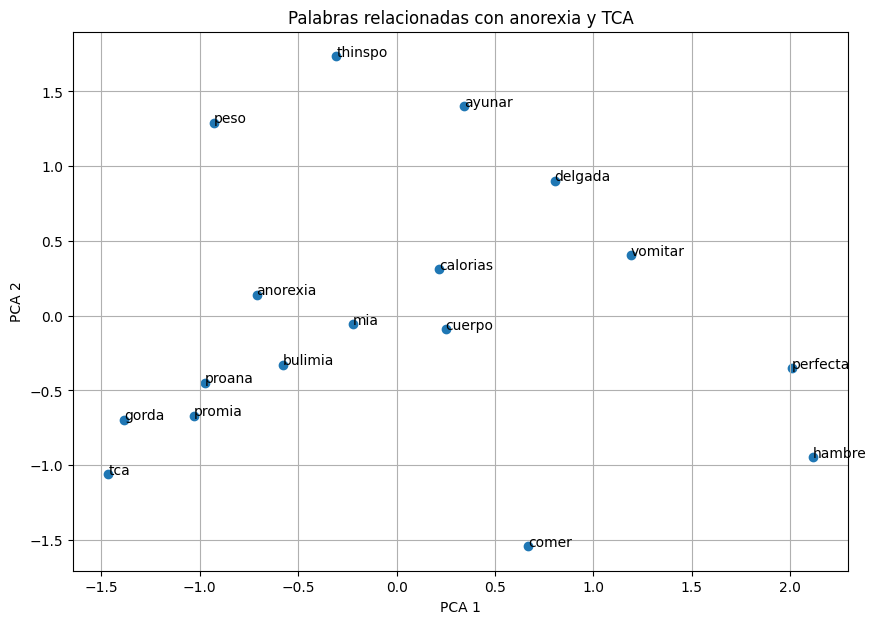

In [22]:
def visualizar_palabras(palabras, titulo="Visualización Word2Vec"):
    palabras_presentes = [p for p in palabras if p in model.wv]
    
    if len(palabras_presentes) < 2:
        print("No hay suficientes palabras presentes en el vocabulario para graficar.")
        return
    
    X = model.wv[palabras_presentes]
    pca = PCA(n_components=2)
    result = pca.fit_transform(X)
    
    plt.figure(figsize=(10, 7))
    plt.scatter(result[:, 0], result[:, 1])
    
    for i, word in enumerate(palabras_presentes):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]))
    
    plt.title(titulo)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.grid(True)
    plt.show()

palabras_tca = [
    "anorexia", "bulimia", "tca", "mia", "proana", "promia",
    "thinspo", "delgada", "gorda", "peso", "calorias", "hambre",
    "comer", "vomitar", "ayunar", "cuerpo", "perfecta", "saludable"
]

visualizar_palabras(palabras_tca, "Palabras relacionadas con anorexia y TCA")

# 10. Visualización de las palabras más frecuentes del vocabulario

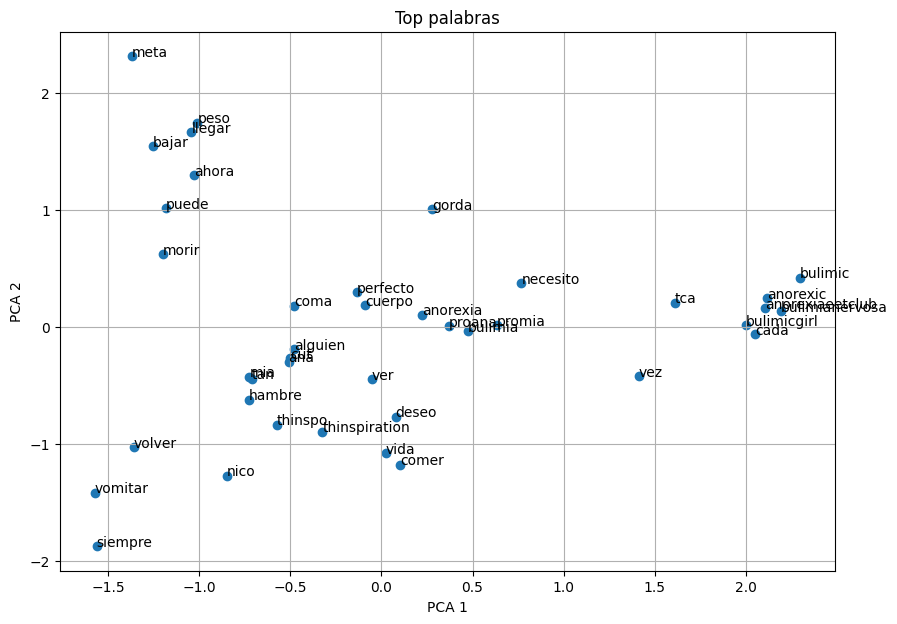

In [23]:
top_words = model.wv.index_to_key[:40]
visualizar_palabras(top_words, "Top palabras")

# 11. Predicción de palabra 

In [24]:
contextos = [
    ["bajar", "peso"],
    ["comer", "culpa"],
    ["anorexia", "bulimia"],
    ["hambre", "agua"],
]

for contexto in contextos:
    contexto_presente = [p for p in contexto if p in model.wv]
    print("\nContexto:", contexto_presente)
    
    if len(contexto_presente) == 0:
        print("Ninguna palabra del contexto está en el vocabulario.")
        continue
    
    try:
        pred = model.predict_output_word(contexto_presente, topn=5)
        print(pred)
    except Exception as e:
        print("No se pudo predecir con este modelo:", e)


Contexto: ['bajar', 'peso']
[('bajar', np.float32(0.14467746)), ('peso', np.float32(0.1164865)), ('cario', np.float32(0.04678407)), ('amor', np.float32(0.04655328)), ('semanas', np.float32(0.042862568))]

Contexto: ['comer']
[('comer', np.float32(0.5562632)), ('acostumbro', np.float32(0.0303638)), ('ruido', np.float32(0.018036786)), ('sabemos', np.float32(0.016975729)), ('desesperas', np.float32(0.01688365))]

Contexto: ['anorexia', 'bulimia']
[('bulimia', np.float32(0.03168146)), ('anorexia', np.float32(0.015843263)), ('obliguen', np.float32(0.0103231575)), ('anorexiarecovery', np.float32(0.010299444)), ('cago', np.float32(0.010027931))]

Contexto: ['hambre']
[('hambre', np.float32(0.35451058)), ('perfecta', np.float32(0.034836818)), ('cortarte', np.float32(0.028637324)), ('huelga', np.float32(0.02746337)), ('hacen', np.float32(0.023710325))]


# 12. Detección simple de posibles señales de anorexia

En esta sección se implementa una detección binaria sencilla para identificar si un tweet contiene posibles señales relacionadas con anorexia o trastornos de la conducta alimentaria.

In [25]:
# ==========================================
# DETECCIÓN AUTOMÁTICA DE POSIBLES SEÑALES
# DE ANOREXIA/TCA EN LOS TWEETS
# ==========================================

import re

# Lista de palabras relacionadas con anorexia/TCA
palabras_riesgo = [
    "anorexia", "anorexica", "proana",
    "no comer", "sin comer", "ayunar",
    "calorias", "bajar de peso", "perder peso",
    "thinspo", "odio mi cuerpo",
    "me siento gorda", "miedo a engordar",
    "vomitar", "atracon", "laxantes"
]

# Función para limpiar texto
def normalizar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+", "", texto)
    texto = re.sub(r"@\w+", "", texto)
    texto = re.sub(r"#", "", texto)
    texto = re.sub(r"[^a-záéíóúñ\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

# Función de detección
def detectar_anorexia_tweet(tweet):

    texto = normalizar_texto(tweet)

    coincidencias = []

    for palabra in palabras_riesgo:
        if normalizar_texto(palabra) in texto:
            coincidencias.append(palabra)

    puntaje = len(coincidencias)

    if puntaje >= 2 or "anorexia" in texto or "proana" in texto:
        resultado = "Posible señal de anorexia/TCA"
    else:
        resultado = "No se detectan señales claras"

    return resultado, puntaje, coincidencias

# ==========================================
# ANALIZAR LOS TWEETS Y MOSTRAR RESULTADOS
# EN UNA TABLA
# ==========================================

resultados = []

tweets_prueba = tweets[:10]

for tweet in tweets_prueba:

    resultado, puntaje, coincidencias = detectar_anorexia_tweet(tweet)

    resultados.append({
        "Tweet": tweet.strip(),
        "Clasificación": resultado,
        "Puntaje": puntaje,
        "Coincidencias": ", ".join(coincidencias)
    })

# Convertimos a DataFrame
df_resultados = pd.DataFrame(resultados)

# Mostrar tabla
df_resultados

,Tweet,Clasificación,Puntaje,Coincidencias
0,A ver cuando se empiezan con las de anorexia y...,Posible señal de anorexia/TCA,1,anorexia
1,"""7 das, 7 razones para entrenar! - Llegamos al...",No se detectan señales claras,0,
2,Como bajar peso comiendo sin parar. Tips,No se detectan señales claras,0,
3,"""No importa si ese platillo luce bien,delicios...",No se detectan señales claras,0,
4,Por supuesto el polo es de fruta y casero Ms f...,No se detectan señales claras,1,sin comer
5,Odio comer como una cerda por ansiedad: hoy he...,No se detectan señales claras,0,
6,"""EMPIEZA LA SEMANA CON MAYOR ENERGIA Y CONCENT...",No se detectan señales claras,0,
7,No le decimos porque creamos que son personas ...,Posible señal de anorexia/TCA,1,anorexia
8,"""Nada, nada! Hay que dar bocados a la vaca viv...",No se detectan señales claras,0,
9,"""Y encima que no es delito? Vergonzoso. Tienda...",No se detectan señales claras,0,


# 13. Cálculo de métricas de evaluación 

En esta sección calcularemos las métricas solicitadas: Accuracy, Precision, Recall, F1-score y AUC para evaluar el rendimiento de la detección de señales de anorexia/TCA.

In [26]:
# ==========================================
# CÁLCULO DE MÉTRICAS DE EVALUACIÓN
# ==========================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Definir ground truth: tweets en df_tca son positivos (1), otros negativos (0)
set_positivos = set(df_tca['tweet_original'])

y_true = [1 if tweet in set_positivos else 0 for tweet in tweets]

# Obtener predicciones y scores
y_pred = []
y_scores = []

for tweet in tweets:
    resultado, puntaje, _ = detectar_anorexia_tweet(tweet)
    y_pred.append(1 if resultado == "Posible señal de anorexia/TCA" else 0)
    y_scores.append(puntaje)  # Usar puntaje como score continuo para AUC

# Calcular métricas
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_scores)  # AUC usando scores

# Mostrar resultados
print("Métricas de evaluación:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Resumen
print("\nResumen:")
print(f"Total de tweets evaluados: {len(tweets)}")
print(f"Tweets positivos (ground truth): {sum(y_true)}")
print(f"Tweets predichos como positivos: {sum(y_pred)}")

Métricas de evaluación:
Accuracy: 0.8440
Precision: 1.0000
Recall: 0.4935
F1-score: 0.6609
AUC: 0.8152

Resumen:
Total de tweets evaluados: 250
Tweets positivos (ground truth): 77
Tweets predichos como positivos: 38
